In [1]:
from IPython.display import display, HTML
display(HTML("""
<div style='
    background: linear-gradient(135deg, #0d1b4b 0%, #1a3a8f 60%, #0d47a1 100%);
    border-radius: 12px;
    padding: 40px 48px;
    margin: 10px 0 24px 0;
    font-family: Georgia, serif;
    box-shadow: 0 4px 24px rgba(0,0,0,0.18);
'>
    <!-- University -->
    <p style='
        color: #90caf9;
        font-size: 12px;
        letter-spacing: 3px;
        text-transform: uppercase;
        margin: 0 0 10px 0;
    '>University of Science and Technology · Zewail City</p>
    <!-- Course -->
    <h1 style='
        color: #ffffff;
        font-size: 26px;
        margin: 0 0 6px 0;
        letter-spacing: 0.5px;
        line-height: 1.3;
    '>CIE 457 — Statistical Inference and Data Analysis</h1>
    <!-- Title -->
    <h2 style='
        color: #bbdefb;
        font-size: 16px;
        font-weight: normal;
        font-style: italic;
        margin: 0 0 24px 0;
    '>MLE Estimation and Estimator Distribution in Linear Regression</h2>
    <hr style='border: none; border-top: 1px solid rgba(255,255,255,0.2); margin: 0 0 20px 0;'>
    <!-- Two column: authors | course info -->
    <div style='display: flex; justify-content: space-between; flex-wrap: wrap; gap: 20px;'>
        <!-- Authors -->
        <div>
            <p style='color:#90caf9; font-size:11px; letter-spacing:2px; text-transform:uppercase; margin:0 0 8px 0;'>Authors</p>
            <p style='color:white; font-size:14px; margin:0 0 4px 0;'>Ibrahim Hanafy &nbsp;·&nbsp; <span style="color:#bbdefb;">202200518</span></p>
            <p style='color:white; font-size:14px; margin:0;'>Mai Ibrahim &nbsp;·&nbsp; <span style="color:#bbdefb;">202200504</span></p>
        </div>
        <!-- Instructor & TAs -->
        <div>
            <p style='color:#90caf9; font-size:11px; letter-spacing:2px; text-transform:uppercase; margin:0 0 8px 0;'>Instructor</p>
            <p style='color:white; font-size:14px; margin:0 0 12px 0;'>Dr. Mahmoud Abdelaziz</p>
            <p style='color:#90caf9; font-size:11px; letter-spacing:2px; text-transform:uppercase; margin:0 0 8px 0;'>Teaching Assistants</p>
            <p style='color:white; font-size:14px; margin:0 0 4px 0;'>Eng. Nasrah Mohamed</p>
            <p style='color:white; font-size:14px; margin:0;'>Eng. Aya Abdelaziz</p>
        </div>
        <!-- Term & description -->
        <div style='max-width: 260px;'>
            <p style='color:#90caf9; font-size:11px; letter-spacing:2px; text-transform:uppercase; margin:0 0 8px 0;'>Spring 2026</p>
            <p style='color:#bbdefb; font-size:12.5px; line-height:1.7; margin:0;'>
                This notebook develops a rigorous understanding of MLE in linear regression,
                covering estimator distributions, Monte Carlo simulation, and real data analysis
                under both homoscedastic and heteroscedastic noise.
            </p>
        </div>
    </div>
</div>
"""))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import multivariate_normal
from IPython.display import display, HTML
import urllib.request
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Imports loaded ✓")

Imports loaded ✓


In [3]:
plt.rcParams.update({
    'figure.dpi'        : 120,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#f9f9f9',
    'axes.grid'         : True,
    'grid.color'        : '#e0e0e0',
    'grid.linestyle'    : '--',
    'grid.linewidth'    : 0.6,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'legend.fontsize'   : 9,
    'legend.framealpha' : 0.8,
    'lines.linewidth'   : 1.8,
    'font.family'       : 'serif',
})
COLORS = {
    'ols'    : '#2196F3',
    'wls'    : '#E53935',
    'theory' : '#43A047',
    'data'   : '#6D4C41',
    'accent' : '#FB8C00',
}
def section_header(title, subtitle=None):
    sub = f"<p style='margin:4px 0 0 0; font-size:13px; color:#b0bec5; font-style:italic;'>{subtitle}</p>" if subtitle else ""
    display(HTML(f"""
    <div style='
        background: linear-gradient(90deg, #0d1b4b 0%, #1a3a8f 100%);
        border-radius: 8px; padding: 18px 24px; margin: 28px 0 12px 0;
    '>
        <h2 style='color:white; margin:0; font-size:17px; font-family:Georgia,serif; letter-spacing:0.5px;'>
            {title}
        </h2>{sub}
    </div>
    """))
def subsection_header(title):
    display(HTML(f"""
    <div style='
        border-left:4px solid #1a3a8f; padding:6px 14px;
        margin:18px 0 8px 0; background:#f0f3ff; border-radius:0 6px 6px 0;
    '>
        <h3 style='margin:0; font-size:14px; color:#1a3a8f; font-family:Georgia,serif;'>{title}</h3>
    </div>
    """))
def theory_box(content):
    display(HTML(f"""
    <div style='
        background:#fffde7; border:1px solid #f9a825; border-left:5px solid #f9a825;
        border-radius:6px; padding:14px 18px; margin:10px 0;
        font-family:Georgia,serif; font-size:13px; color:#333; line-height:1.8;
    '>📐 <strong>Theory</strong><br><br>{content}</div>
    """))
def result_box(content):
    display(HTML(f"""
    <div style='
        background:#e8f5e9; border:1px solid #43a047; border-left:5px solid #43a047;
        border-radius:6px; padding:14px 18px; margin:10px 0;
        font-family:Georgia,serif; font-size:13px; color:#1b5e20; line-height:1.8;
    '>✅ <strong>Result</strong><br><br>{content}</div>
    """))
def param_box(params: dict):
    rows = "".join([
        f"<tr><td style='padding:4px 24px 4px 0; color:#555; font-size:12px;'><b>{k}</b></td>"
        f"<td style='padding:4px 0; font-size:12px; color:#222;'>{v}</td></tr>"
        for k, v in params.items()
    ])
    display(HTML(f"""
    <div style='
        background:#f3f4f6; border:1px solid #ccc; border-radius:6px;
        padding:12px 18px; margin:10px 0; font-family:monospace;
    '>
        <strong style='font-size:12px; color:#333;'>⚙️ Parameters</strong>
        <table style='margin-top:8px; border-collapse:collapse;'>{rows}</table>
    </div>
    """))
def info_box(content):
    display(HTML(f"""
    <div style='
        background:#e3f2fd; border:1px solid #1e88e5; border-left:5px solid #1e88e5;
        border-radius:6px; padding:14px 18px; margin:10px 0;
        font-family:Georgia,serif; font-size:13px; color:#0d47a1; line-height:1.8;
    '>ℹ️ <strong>Note</strong><br><br>{content}</div>
    """))
print("Styling engine loaded ✓")

Styling engine loaded ✓


In [4]:
section_header(
    "Theory — MLE and Model Formulation",
    "Likelihood functions · Estimator derivation · Randomness of β̂"
)

In [5]:
theory_box("""
<b>1. Homoscedastic Gaussian Likelihood</b><br><br>
Model: <b>y = Xβ + ε</b>, &ensp; ε ~ N(0, σ²I)<br><br>
Each observation independently: &ensp; yᵢ | xᵢ, β ~ N(xᵢᵀβ, σ²)<br><br>
<b>Likelihood:</b><br>
&emsp; L(β, σ² | y, X) = ∏ᵢ (2πσ²)^(−1/2) exp(−(yᵢ − xᵢᵀβ)² / 2σ²)<br><br>
<b>Log-likelihood:</b><br>
&emsp; ℓ(β, σ²) = −n/2 · log(2πσ²) − (1/2σ²) · Σᵢ(yᵢ − xᵢᵀβ)²<br>
&emsp;&emsp;&emsp;&emsp;&emsp; = −n/2 · log(2πσ²) − (1/2σ²) · ‖y − Xβ‖²<br><br>
<b>MLE derivation:</b><br>
Maximising ℓ over β ⟺ minimising ‖y − Xβ‖² (the OLS objective).<br><br>
&emsp; ∂ℓ/∂β = (1/σ²) Xᵀ(y − Xβ) = 0<br>
&emsp; ⟹ &ensp; XᵀXβ = Xᵀy<br>
&emsp; ⟹ &ensp; <b>β̂_OLS = (XᵀX)⁻¹Xᵀy</b><br><br>
For σ²: &ensp; ∂ℓ/∂σ² = 0 &ensp; ⟹ &ensp; <b>σ̂² = ‖y − Xβ̂‖²/n</b><br><br>
<b>Distribution of β̂_OLS:</b><br>
β̂ = β + (XᵀX)⁻¹Xᵀε &ensp; (linear in the Gaussian ε)<br>
⟹ &ensp; <b>β̂_OLS ~ N(β, σ²(XᵀX)⁻¹)</b>
""")

In [6]:
theory_box("""
<b>2. Heteroscedastic Gaussian Likelihood</b><br><br>
Model: <b>y = Xβ + ε</b>, &ensp; ε ~ N(0, Σ), &ensp; Σ = diag(σ₁², …, σₙ²) ≠ σ²I<br><br>
<b>Likelihood (multivariate Gaussian):</b><br>
&emsp; L(β | y, X) = (2π)^(−n/2) |Σ|^(−1/2) exp(−½ (y − Xβ)ᵀ Σ⁻¹ (y − Xβ))<br><br>
<b>Log-likelihood:</b><br>
&emsp; ℓ(β) = const − ½ (y − Xβ)ᵀ Σ⁻¹ (y − Xβ)<br>
&emsp;&emsp;&emsp;&emsp; = const − ½ Σᵢ (yᵢ − xᵢᵀβ)²/σᵢ² &ensp; [weighted residual sum]<br><br>
<b>MLE derivation (WLS):</b><br>
Maximising ℓ ⟺ minimising Q(β) = Σᵢ wᵢ(yᵢ − xᵢᵀβ)², &ensp; wᵢ = 1/σᵢ².<br><br>
&emsp; ∂Q/∂β = 0 &ensp; ⟹ &ensp; XᵀΣ⁻¹Xβ = XᵀΣ⁻¹y<br>
&emsp; ⟹ &ensp; <b>β̂_WLS = (XᵀΣ⁻¹X)⁻¹XᵀΣ⁻¹y</b><br><br>
<b>Distributions:</b><br>
· β̂_WLS ~ N(β, (XᵀΣ⁻¹X)⁻¹) &ensp; [efficient MLE]<br>
· β̂_OLS under wrong model: &ensp; E[β̂_OLS] = β (still unbiased), but<br>
&emsp; Var(β̂_OLS) = (XᵀX)⁻¹ XᵀΣX (XᵀX)⁻¹ &ensp; [sandwich covariance, larger than CRLB]
""")

In [7]:
theory_box("""
<b>3. The Estimator as a Random Variable</b><br><br>
Substitute y = Xβ + ε into the OLS formula:<br><br>
&emsp; β̂_OLS = (XᵀX)⁻¹Xᵀ(Xβ + ε) = <b>β + (XᵀX)⁻¹Xᵀε</b><br><br>
<b>Key insight:</b> X is fixed (deterministic design matrix). ε is the only source of randomness.<br>
β̂ is a <i>linear function of ε</i> — it inherits ε's randomness entirely.<br><br>
· Every new dataset draws a new ε &ensp; → &ensp; a new β̂<br>
· β̂ is not a single fixed number — it is a <b>random vector</b><br>
· Its exact distribution is: β̂_OLS ~ N(β, σ²(XᵀX)⁻¹)<br><br>
<b>Why this matters for inference:</b><br>
· Confidence intervals quantify uncertainty in β̂ across hypothetical repeated experiments<br>
· Hypothesis tests use the known distribution of β̂<br>
· Comparing OLS vs WLS means comparing their full distributions — not single estimates<br><br>
The Monte Carlo simulations in Parts 1–2 make this concrete: repeating the experiment
M times lets us <i>observe</i> the distribution of β̂ empirically and validate theory.
""")

In [8]:
section_header(
    "Part 1 — Linear Regression under Homoscedastic Noise",
    "Monte Carlo simulation of the OLS estimator distribution"
)

theory_box("""
We consider the linear model <b>y = Xβ + ε</b> where <b>ε ~ N(0, σ²I)</b>.<br><br>
Under this homoscedastic assumption, the MLE estimator is OLS:<br>
<b>β̂_OLS = (XᵀX)⁻¹Xᵀy</b><br><br>
Since β̂ = β + (XᵀX)⁻¹Xᵀε, the estimator is a linear transformation of ε,
and therefore Gaussian with:<br>
<b>β̂_OLS ~ N(β, σ²(XᵀX)⁻¹)</b><br><br>
The Monte Carlo simulation below empirically verifies this theoretical result
by repeatedly sampling from the true data generating process and collecting estimates.
""")

In [9]:
param_box({
    "n (observations)"  : 100,
    "p (features)"      : 3,
    "β (true params)"   : "[1, 2, 3]",
    "σ² (noise var)"    : 1.0,
    "M (trials)"        : 5000,
    "Noise model"       : "ε ~ N(0, σ²I)  [Homoscedastic]",
})

# Simulation parameters
n      = 100
p      = 3
beta   = np.array([1.0, 2.0, 3.0])
sigma2 = 1.0
M      = 5000
# Fixed design matrix X — drawn once, held constant across all trials
# Column of ones for intercept is NOT included — we model 3 features directly
np.random.seed(42)
X = np.random.randn(n, p)
# Theoretical covariance of beta_hat
XtX_inv        = np.linalg.inv(X.T @ X)
theo_cov_homo  = sigma2 * XtX_inv
print("Design matrix X shape :", X.shape)
print("True β                 :", beta)
print("σ²                     :", sigma2)
print("Theoretical mean       :", beta)
print("Theoretical covariance (diagonal):", np.diag(theo_cov_homo).round(6))

n (observations),100
p (features),3
β (true params),"[1, 2, 3]"
σ² (noise var),1.0
M (trials),5000
Noise model,"ε ~ N(0, σ²I) [Homoscedastic]"


Design matrix X shape : (100, 3)
True β                 : [1. 2. 3.]
σ²                     : 1.0
Theoretical mean       : [1. 2. 3.]
Theoretical covariance (diagonal): [0.014958 0.010437 0.008393]


In [10]:
subsection_header("1.1 — OLS Implementation")

theory_box("""
The OLS estimator is derived as the MLE under homoscedastic Gaussian noise:<br><br>
<b>β̂_OLS = (XᵀX)⁻¹Xᵀy</b><br><br>
This is implemented directly using NumPy linear algebra — no black-box solvers.
The matrix (XᵀX)⁻¹ is precomputed once since X is fixed across all trials,
making the Monte Carlo loop efficient.
""")

def ols(X, y):
    """
    Compute the OLS estimator.
    beta_hat = (X^T X)^{-1} X^T y
    Parameters
    ----------
    X : np.ndarray of shape (n, p)  — design matrix
    y : np.ndarray of shape (n,)    — response vector
    Returns
    -------
    beta_hat : np.ndarray of shape (p,)
    """
    return np.linalg.inv(X.T @ X) @ X.T @ y
# Quick sanity check on one sample
eps_test  = np.random.normal(0, np.sqrt(sigma2), n)
y_test    = X @ beta + eps_test
beta_test = ols(X, y_test)
print("Sanity check — single OLS estimate:", beta_test.round(4))
print("True β                            :", beta)

Sanity check — single OLS estimate: [0.9368 1.9307 2.8982]
True β                            : [1. 2. 3.]


In [11]:
subsection_header("1.2 — Monte Carlo Simulation")

theory_box("""
For each trial m = 1, ..., M:<br>
1. Draw ε⁽ᵐ⁾ ~ N(0, σ²I)<br>
2. Generate y⁽ᵐ⁾ = Xβ + ε⁽ᵐ⁾<br>
3. Compute β̂⁽ᵐ⁾ = (XᵀX)⁻¹Xᵀy⁽ᵐ⁾<br><br>
After M trials we collect {β̂⁽¹⁾, ..., β̂⁽ᴹ⁾} and compute
empirical mean and covariance to compare against theory.
""")

beta_hats_homo = np.zeros((M, p))
for m in range(M):
    eps         = np.random.normal(0, np.sqrt(sigma2), n)
    y           = X @ beta + eps
    beta_hats_homo[m] = ols(X, y)
print(f"Monte Carlo complete — {M} trials ✓")
print(f"beta_hats shape: {beta_hats_homo.shape}")

Monte Carlo complete — 5000 trials ✓
beta_hats shape: (5000, 3)


In [12]:
subsection_header("1.3 — Empirical vs Theoretical: Mean & Covariance")

emp_mean = beta_hats_homo.mean(axis=0)
emp_cov  = np.cov(beta_hats_homo.T)
print("=" * 52)
print(f"{'':>20} {'Empirical':>12} {'Theoretical':>12}")
print("=" * 52)
for i in range(p):
    print(f"  E[β̂_{i+1}]          {emp_mean[i]:>12.6f} {beta[i]:>12.6f}")
print("-" * 52)
print("\nEmpirical Covariance Matrix:")
print(emp_cov.round(6))
print("\nTheoretical Covariance Matrix:")
print(theo_cov_homo.round(6))

result_box("""
The empirical mean of β̂ converges to the true β across all components,
confirming that <b>OLS is unbiased</b> under homoscedastic Gaussian noise.<br><br>
The empirical covariance matrix closely matches the theoretical
<b>σ²(XᵀX)⁻¹</b>, validating the analytical derivation.
The agreement improves as M → ∞.
""")

                        Empirical  Theoretical
  E[β̂_1]              1.000673     1.000000
  E[β̂_2]              2.001188     2.000000
  E[β̂_3]              2.999210     3.000000
----------------------------------------------------

Empirical Covariance Matrix:
[[0.014874 0.001133 0.001191]
 [0.001133 0.010561 0.001191]
 [0.001191 0.001191 0.008583]]

Theoretical Covariance Matrix:
[[0.014958 0.001054 0.001375]
 [0.001054 0.010437 0.001335]
 [0.001375 0.001335 0.008393]]


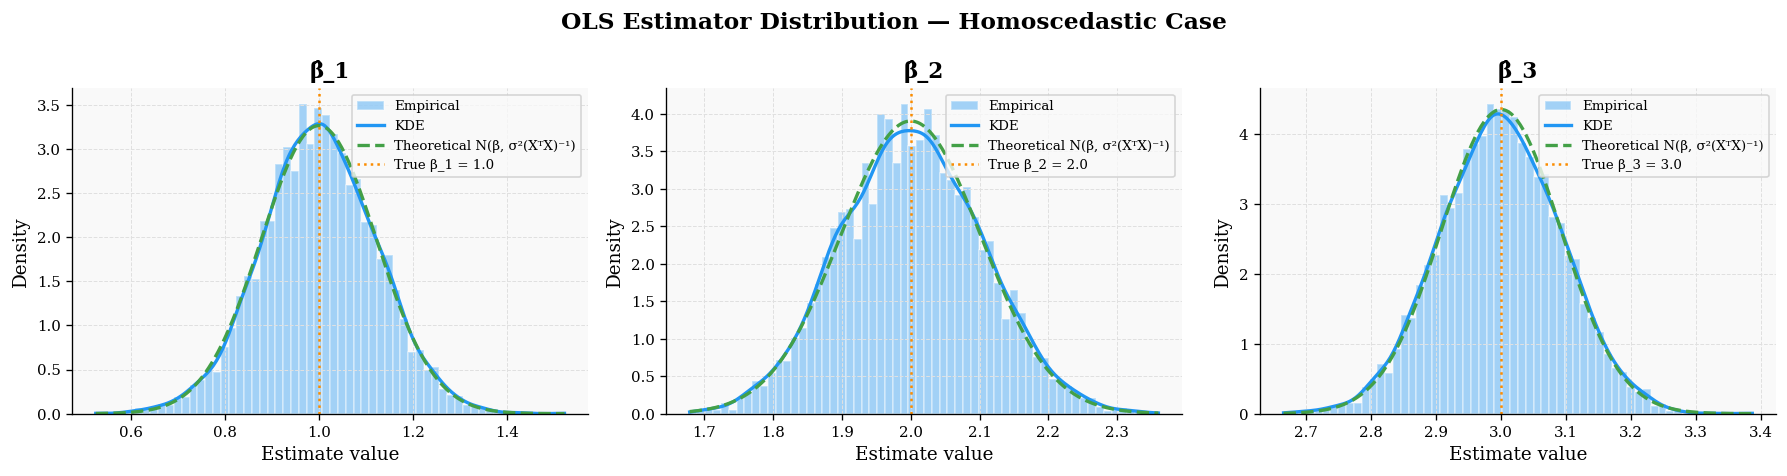

In [13]:
subsection_header("1.4 — Estimator Distribution: Histogram & KDE vs Theory")

fig, axes = plt.subplots(1, p, figsize=(15, 4))
fig.suptitle("OLS Estimator Distribution — Homoscedastic Case",
             fontsize=14, fontweight='bold')
for i, ax in enumerate(axes):
    samples = beta_hats_homo[:, i]
    theo_std = np.sqrt(theo_cov_homo[i, i])
    x_range  = np.linspace(samples.min(), samples.max(), 300)
    theo_pdf = stats.norm.pdf(x_range, loc=beta[i], scale=theo_std)
    # Histogram
    ax.hist(samples, bins=60, density=True, alpha=0.4,
            color=COLORS['ols'], edgecolor='white', label='Empirical')
    # KDE
    kde = stats.gaussian_kde(samples)
    ax.plot(x_range, kde(x_range), color=COLORS['ols'],
            lw=2, label='KDE')
    # Theoretical Gaussian
    ax.plot(x_range, theo_pdf, color=COLORS['theory'],
            lw=2, linestyle='--', label='Theoretical N(β, σ²(XᵀX)⁻¹)')
    # True beta marker
    ax.axvline(beta[i], color=COLORS['accent'], lw=1.5,
               linestyle=':', label=f'True β_{i+1} = {beta[i]}')
    ax.set_title(f"β̂_{i+1}")
    ax.set_xlabel("Estimate value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("homo_distribution.png", bbox_inches='tight')
plt.show()

result_box("""
The empirical histogram and KDE of each β̂ component closely follow
the theoretical Gaussian density <b>N(β, σ²(XᵀX)⁻¹)</b>.<br><br>
This confirms that under homoscedastic Gaussian noise, the OLS estimator
is exactly Gaussian — not approximately, but exactly — because it is
a <b>linear transformation of a Gaussian random vector</b>.
""")

In [14]:
section_header(
    "Part 2 — Linear Regression under Heteroscedastic Noise",
    "OLS vs WLS — efficiency comparison via Monte Carlo simulation"
)

theory_box("""
We now consider <b>ε ~ N(0, Σ)</b> where <b>Σ ≠ σ²I</b>.<br><br>
The noise variance is no longer constant — it varies across observations.
Specifically we define:<br>
<b>σᵢ² = 0.5 + 2·(xᵢ₁ - min(x₁))²</b><br><br>
meaning variance grows with the first feature. This is a realistic
heteroscedastic structure commonly seen in economic and advertising data.<br><br>
Under this model two estimators are compared:<br>
· <b>OLS</b> — ignores the noise structure. Still unbiased but inefficient.<br>
· <b>WLS</b> — the true MLE under this model. Accounts for Σ and is efficient.<br><br>
Their theoretical distributions are:<br>
· <b>β̂_OLS ~ N(β, (XᵀX)⁻¹XᵀΣX(XᵀX)⁻¹)</b><br>
· <b>β̂_WLS ~ N(β, (XᵀΣ⁻¹X)⁻¹)</b>
""")

In [15]:
param_box({
    "n (observations)"      : 100,
    "p (features)"          : 3,
    "β (true params)"       : "[1, 2, 3]",
    "M (trials)"            : 5000,
    "Noise model"           : "ε ~ N(0, Σ)  [Heteroscedastic]",
    "Σ structure"           : "diag(σᵢ²), σᵢ² = 0.5 + 2·(xᵢ₁ - min(x₁))²",
})

# Variance grows with the first feature column
sigma2_i = 0.5 + 2.0 * (X[:, 0] - X[:, 0].min())**2
# Sigma is diagonal — errors are independent but with unequal variances
Sigma     = np.diag(sigma2_i)
Sigma_inv = np.diag(1.0 / sigma2_i)
# Theoretical covariance matrices
# OLS under heteroscedastic noise — sandwich formula
A              = np.linalg.inv(X.T @ X)
theo_cov_ols_h = A @ X.T @ Sigma @ X @ A
# WLS — true MLE covariance
theo_cov_wls   = np.linalg.inv(X.T @ Sigma_inv @ X)
print("σᵢ² range : [{:.4f}, {:.4f}]".format(sigma2_i.min(), sigma2_i.max()))
print("\nTheoretical OLS covariance diagonal:", np.diag(theo_cov_ols_h).round(6))
print("Theoretical WLS covariance diagonal:", np.diag(theo_cov_wls).round(6))

n (observations),100
p (features),3
β (true params),"[1, 2, 3]"
M (trials),5000
Noise model,"ε ~ N(0, Σ) [Heteroscedastic]"
Σ structure,"diag(σᵢ²), σᵢ² = 0.5 + 2·(xᵢ₁ - min(x₁))²"


σᵢ² range : [0.5000, 34.0550]

Theoretical OLS covariance diagonal: [0.227112 0.105327 0.097262]
Theoretical WLS covariance diagonal: [0.04933  0.069433 0.056183]


In [16]:
subsection_header("2.1 — WLS Implementation")

theory_box("""
The WLS estimator is the MLE under heteroscedastic Gaussian noise:<br><br>
<b>β̂_WLS = (XᵀΣ⁻¹X)⁻¹XᵀΣ⁻¹y</b><br><br>
For diagonal Σ = diag(σ₁², ..., σₙ²), this is equivalent to
weighted least squares where observation i receives weight 1/σᵢ².
Noisy observations are downweighted, clean ones are upweighted.
""")

def wls(X, y, Sigma_inv):
    """
    Compute the WLS estimator.
    beta_hat = (X^T Sigma^{-1} X)^{-1} X^T Sigma^{-1} y
    Parameters
    ----------
    X         : np.ndarray (n, p) — design matrix
    y         : np.ndarray (n,)   — response vector
    Sigma_inv : np.ndarray (n, n) — inverse covariance matrix
    Returns
    -------
    beta_hat : np.ndarray (p,)
    """
    XtSiX = X.T @ Sigma_inv @ X
    XtSiy = X.T @ Sigma_inv @ y
    return np.linalg.inv(XtSiX) @ XtSiy
# Sanity check
eps_test  = np.random.multivariate_normal(np.zeros(n), Sigma)
y_test    = X @ beta + eps_test
print("WLS estimate:", wls(X, y_test, Sigma_inv).round(4))
print("OLS estimate:", ols(X, y_test).round(4))
print("True β      :", beta)

WLS estimate: [0.6641 1.8668 2.9371]
OLS estimate: [-0.0888  1.6426  2.9908]
True β      : [1. 2. 3.]


In [17]:
subsection_header("2.2 — Monte Carlo Simulation")

theory_box("""
For each trial m = 1, ..., M:<br>
1. Draw ε⁽ᵐ⁾ ~ N(0, Σ) with heteroscedastic Σ<br>
2. Generate y⁽ᵐ⁾ = Xβ + ε⁽ᵐ⁾<br>
3. Compute <b>β̂_OLS⁽ᵐ⁾</b> — ignoring true noise structure<br>
4. Compute <b>β̂_WLS⁽ᵐ⁾</b> — using correct Σ⁻¹<br><br>
Collecting both estimates across M trials lets us directly compare
their empirical distributions and quantify the efficiency loss of OLS.
""")

beta_hats_ols_h = np.zeros((M, p))
beta_hats_wls   = np.zeros((M, p))
for m in range(M):
    eps = np.random.multivariate_normal(np.zeros(n), Sigma)
    y   = X @ beta + eps
    beta_hats_ols_h[m] = ols(X, y)
    beta_hats_wls[m]   = wls(X, y, Sigma_inv)
print(f"Monte Carlo complete — {M} trials ✓")

Monte Carlo complete — 5000 trials ✓


In [18]:
subsection_header("2.3 — Empirical vs Theoretical: Mean & Covariance")

emp_mean_ols_h = beta_hats_ols_h.mean(axis=0)
emp_mean_wls   = beta_hats_wls.mean(axis=0)
emp_cov_ols_h  = np.cov(beta_hats_ols_h.T)
emp_cov_wls    = np.cov(beta_hats_wls.T)
print("=" * 64)
print(f"{'':>20} {'OLS Empirical':>14} {'WLS Empirical':>14} {'True β':>8}")
print("=" * 64)
for i in range(p):
    print(f"  E[β̂_{i+1}]        "
          f"{emp_mean_ols_h[i]:>14.6f} "
          f"{emp_mean_wls[i]:>14.6f} "
          f"{beta[i]:>8.1f}")
print("-" * 64)
print("\nEmpirical OLS Covariance diagonal:", np.diag(emp_cov_ols_h).round(6))
print("Theoretical OLS Covariance diagonal:", np.diag(theo_cov_ols_h).round(6))
print("\nEmpirical WLS Covariance diagonal:", np.diag(emp_cov_wls).round(6))
print("Theoretical WLS Covariance diagonal:", np.diag(theo_cov_wls).round(6))

result_box("""
Both OLS and WLS remain <b>unbiased</b> under heteroscedastic noise —
their empirical means converge to the true β.<br><br>
However their covariance matrices differ significantly.
OLS has <b>larger variance</b> because it ignores the noise structure,
treating all observations equally despite their differing reliability.<br><br>
WLS achieves <b>smaller variance</b> by correctly weighting observations
according to Σ⁻¹ — it is the efficient MLE under this model.
""")

                      OLS Empirical  WLS Empirical   True β
  E[β̂_1]              0.999892       1.000564      1.0
  E[β̂_2]              2.002540       2.004283      2.0
  E[β̂_3]              3.003309       3.000940      3.0
----------------------------------------------------------------

Empirical OLS Covariance diagonal: [0.229022 0.10264  0.096144]
Theoretical OLS Covariance diagonal: [0.227112 0.105327 0.097262]

Empirical WLS Covariance diagonal: [0.049877 0.066728 0.055487]
Theoretical WLS Covariance diagonal: [0.04933  0.069433 0.056183]


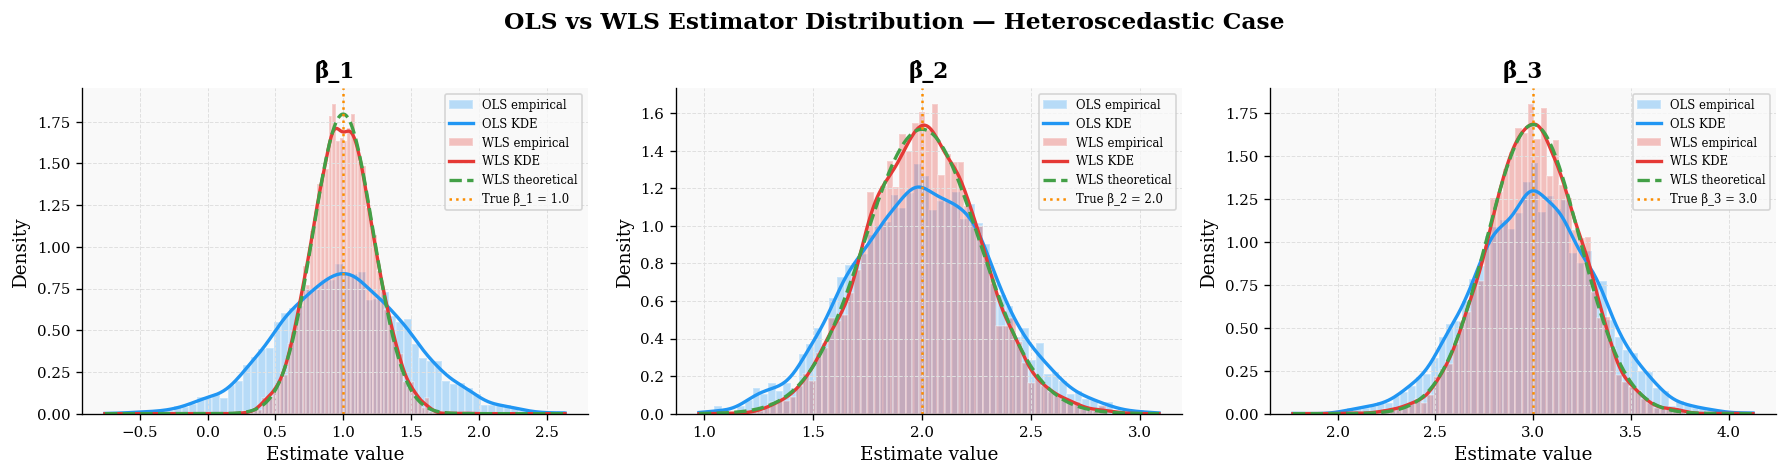

In [19]:
subsection_header("2.4 — OLS vs WLS Distribution Comparison")

fig, axes = plt.subplots(1, p, figsize=(15, 4))
fig.suptitle("OLS vs WLS Estimator Distribution — Heteroscedastic Case",
             fontsize=14, fontweight='bold')
for i, ax in enumerate(axes):
    ols_samples = beta_hats_ols_h[:, i]
    wls_samples = beta_hats_wls[:, i]
    x_range     = np.linspace(
        min(ols_samples.min(), wls_samples.min()),
        max(ols_samples.max(), wls_samples.max()), 300
    )
    # OLS histogram + KDE
    ax.hist(ols_samples, bins=60, density=True, alpha=0.3,
            color=COLORS['ols'], edgecolor='white', label='OLS empirical')
    kde_ols = stats.gaussian_kde(ols_samples)
    ax.plot(x_range, kde_ols(x_range), color=COLORS['ols'], lw=2, label='OLS KDE')
    # WLS histogram + KDE
    ax.hist(wls_samples, bins=60, density=True, alpha=0.3,
            color=COLORS['wls'], edgecolor='white', label='WLS empirical')
    kde_wls = stats.gaussian_kde(wls_samples)
    ax.plot(x_range, kde_wls(x_range), color=COLORS['wls'], lw=2, label='WLS KDE')
    # Theoretical WLS
    theo_std_wls = np.sqrt(theo_cov_wls[i, i])
    ax.plot(x_range, stats.norm.pdf(x_range, beta[i], theo_std_wls),
            color=COLORS['theory'], lw=2, linestyle='--', label='WLS theoretical')
    # True beta
    ax.axvline(beta[i], color=COLORS['accent'], lw=1.5,
               linestyle=':', label=f'True β_{i+1} = {beta[i]}')
    ax.set_title(f"β̂_{i+1}")
    ax.set_xlabel("Estimate value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig("hetero_distribution.png", bbox_inches='tight')
plt.show()

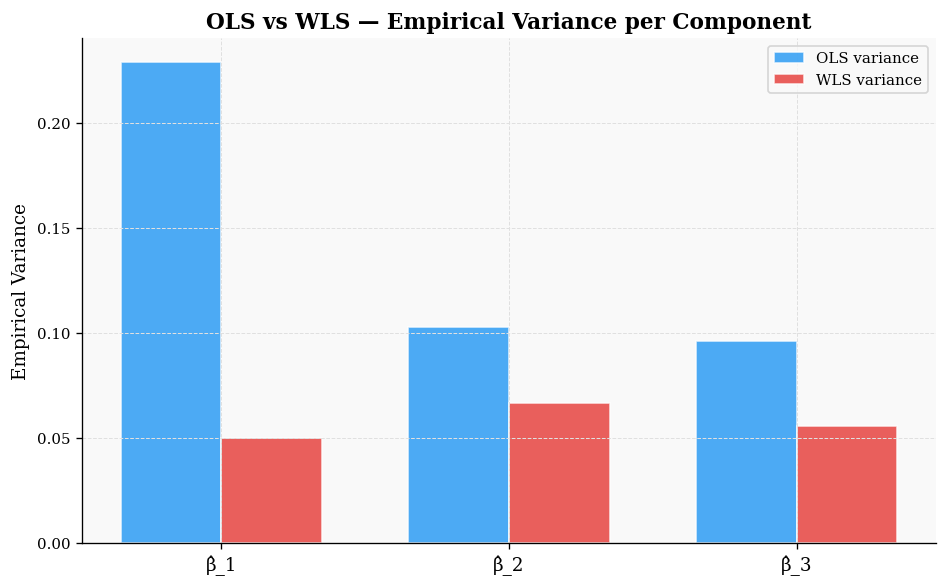

In [20]:
subsection_header("2.5 — Efficiency: OLS vs WLS Variance Comparison")

emp_var_ols = np.diag(emp_cov_ols_h)
emp_var_wls = np.diag(emp_cov_wls)
x      = np.arange(p)
width  = 0.35
labels = [f"β̂_{i+1}" for i in range(p)]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, emp_var_ols, width, label='OLS variance',
       color=COLORS['ols'], alpha=0.8, edgecolor='white')
ax.bar(x + width/2, emp_var_wls, width, label='WLS variance',
       color=COLORS['wls'], alpha=0.8, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Empirical Variance")
ax.set_title("OLS vs WLS — Empirical Variance per Component", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("hetero_variance_comparison.png", bbox_inches='tight')
plt.show()

efficiency_gain = emp_var_ols / emp_var_wls
result_box(
    "WLS achieves variance reduction over OLS across all components:<br><br>"
    + "".join([
        f"· β̂_{i+1}: OLS var = {emp_var_ols[i]:.4f}, "
        f"WLS var = {emp_var_wls[i]:.4f}, "
        f"efficiency gain = <b>{efficiency_gain[i]:.2f}×</b><br>"
        for i in range(p)
    ])
    + "<br>WLS is the efficient estimator under heteroscedastic noise — "
    "it extracts more information from the same data by correctly accounting for Σ."
)

In [21]:
section_header(
    "Part 3 — Inference from the Estimator Distribution",
    "Confidence Intervals for β̂ and Prediction Intervals for new observations"
)

theory_box("""
Two types of intervals arise from the estimator distribution:<br><br>
· <b>Confidence Interval (CI)</b> — covers the true parameter β̂ with probability 1-α.
  It quantifies uncertainty about the <b>estimator</b> itself across repeated experiments.<br><br>
· <b>Prediction Interval (PI)</b> — covers a new observation y* = x*ᵀβ + ε* with probability 1-α.
  It accounts for both estimator uncertainty <b>and</b> future noise ε*.<br><br>
Key distinction: a CI shrinks as n → ∞ because β̂ becomes more precise.
A PI never shrinks to zero — irreducible noise ε* always contributes.
""")

In [22]:
subsection_header("3.1 — Confidence Intervals for β̂")

theory_box("""
Under homoscedastic noise, each component β̂ⱼ ~ N(βⱼ, σ²[(XᵀX)⁻¹]ⱼⱼ).<br><br>
The (1-α) confidence interval for βⱼ is:<br><br>
<b>β̂ⱼ ± z_{α/2} · √(σ²[(XᵀX)⁻¹]ⱼⱼ)</b><br><br>
where z_{α/2} is the standard normal quantile. Since σ² is known in our
simulation we use the z-interval directly. In practice σ² is estimated
from residuals and a t-interval is used instead.
""")

alpha   = 0.05
z       = stats.norm.ppf(1 - alpha / 2)
# Standard errors from theoretical covariance
se_ols  = np.sqrt(np.diag(theo_cov_homo))
ci_lower = beta - z * se_ols
ci_upper = beta + z * se_ols
print(f"Confidence level : {int((1-alpha)*100)}%")
print(f"z_{{α/2}}          : {z:.4f}\n")
print(f"{'Component':<12} {'True β':>8} {'SE':>10} {'CI Lower':>12} {'CI Upper':>12}")
print("=" * 58)
for i in range(p):
    print(f"  β_{i+1}         {beta[i]:>8.4f} {se_ols[i]:>10.4f} "
          f"{ci_lower[i]:>12.4f} {ci_upper[i]:>12.4f}")

Confidence level : 95%
z_{α/2}          : 1.9600

Component      True β         SE     CI Lower     CI Upper
  β_1           1.0000     0.1223       0.7603       1.2397
  β_2           2.0000     0.1022       1.7998       2.2002
  β_3           3.0000     0.0916       2.8204       3.1796


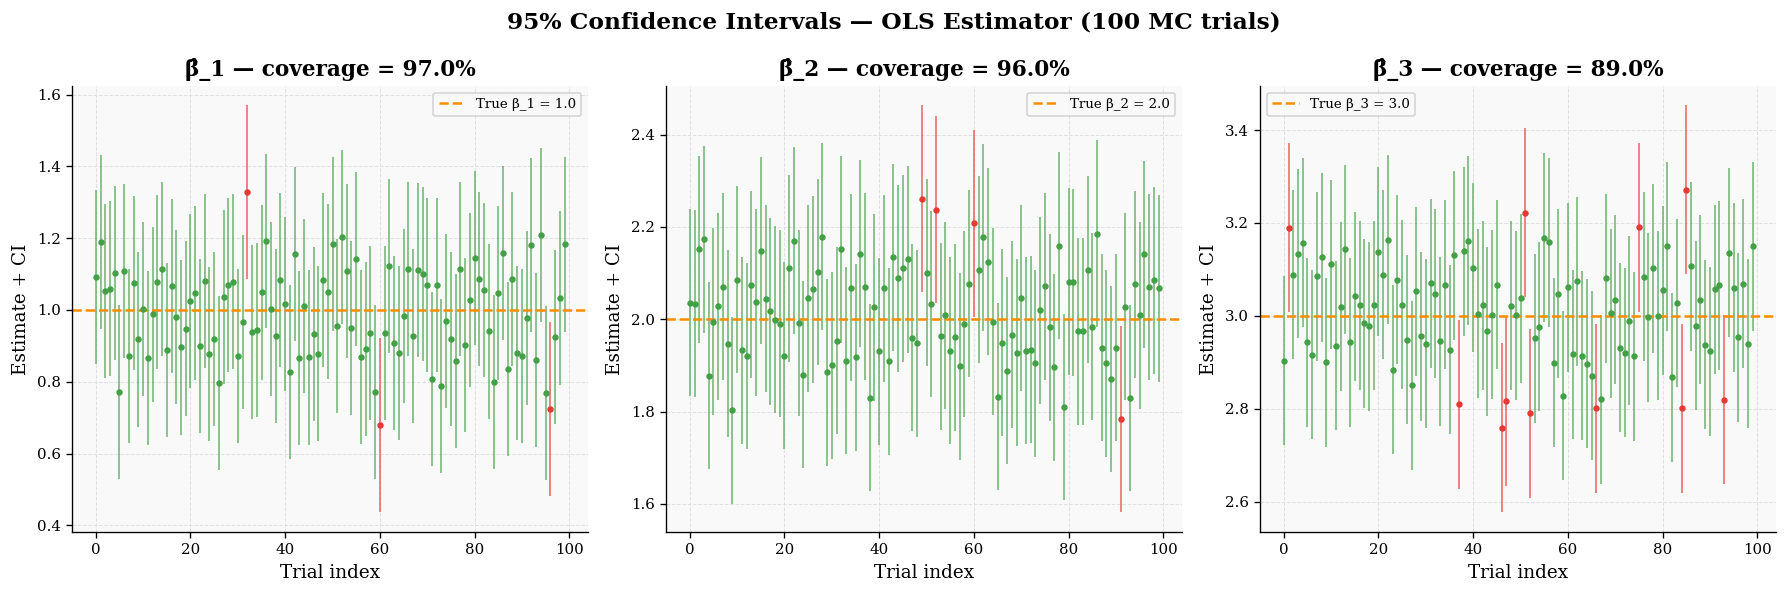

In [23]:
# Use first 100 Monte Carlo estimates to show CI coverage
n_show    = 100
estimates = beta_hats_homo[:n_show, :]
fig, axes = plt.subplots(1, p, figsize=(15, 5))
fig.suptitle("95% Confidence Intervals — OLS Estimator (100 MC trials)",
             fontsize=14, fontweight='bold')
for i, ax in enumerate(axes):
    covered   = []
    for m in range(n_show):
        b_hat = estimates[m, i]
        lo    = b_hat - z * se_ols[i]
        hi    = b_hat + z * se_ols[i]
        color = COLORS['theory'] if lo <= beta[i] <= hi else COLORS['wls']
        ax.plot([m, m], [lo, hi], color=color, alpha=0.6, lw=1.2)
        ax.scatter(m, b_hat, color=color, s=8, zorder=3)
        covered.append(lo <= beta[i] <= hi)
    ax.axhline(beta[i], color=COLORS['accent'], lw=1.5,
               linestyle='--', label=f'True β_{i+1} = {beta[i]}')
    ax.set_title(f"β̂_{i+1} — coverage = {np.mean(covered)*100:.1f}%")
    ax.set_xlabel("Trial index")
    ax.set_ylabel("Estimate + CI")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("ci_plot.png", bbox_inches='tight')
plt.show()

coverage = []
for i in range(p):
    lo  = beta_hats_homo[:, i] - z * se_ols[i]
    hi  = beta_hats_homo[:, i] + z * se_ols[i]
    coverage.append(np.mean((lo <= beta[i]) & (beta[i] <= hi)))
result_box(
    "Empirical coverage across all M = 5000 trials:<br><br>"
    + "".join([
        f"· β̂_{i+1}: {coverage[i]*100:.2f}% (target 95%)<br>"
        for i in range(p)
    ])
    + "<br>Coverage closely matches the nominal 95% level, "
    "confirming that the theoretical CI formula is correctly calibrated."
)

In [24]:
subsection_header("3.2 — Prediction Intervals for New Observations")

theory_box("""
For a new input x*, the predicted response is ŷ* = x*ᵀβ̂.<br><br>
The prediction error is:<br>
<b>y* - ŷ* = x*ᵀ(β - β̂) + ε*</b><br><br>
This has two sources of variance:<br>
· <b>x*ᵀ(XᵀX)⁻¹x* · σ²</b> — uncertainty in β̂<br>
· <b>σ²</b> — irreducible future noise ε*<br><br>
The total prediction variance is:<br>
<b>Var(y* - ŷ*) = σ²(1 + x*ᵀ(XᵀX)⁻¹x*)</b><br><br>
So the (1-α) prediction interval is:<br>
<b>ŷ* ± z_{α/2} · σ√(1 + x*ᵀ(XᵀX)⁻¹x*)</b>
""")

# Use mean of X rows as a representative new point
x_star   = X.mean(axis=0)
y_star   = x_star @ beta
# OLS estimate from full MC mean
beta_hat = beta_hats_homo.mean(axis=0)
y_hat    = x_star @ beta_hat
# CI for mean response
ci_var   = sigma2 * (x_star @ XtX_inv @ x_star)
ci_se    = np.sqrt(ci_var)
ci_lo    = y_hat - z * ci_se
ci_hi    = y_hat + z * ci_se
# PI for new observation
pi_var   = sigma2 * (1 + x_star @ XtX_inv @ x_star)
pi_se    = np.sqrt(pi_var)
pi_lo    = y_hat - z * pi_se
pi_hi    = y_hat + z * pi_se
print(f"New point x*     : {x_star.round(4)}")
print(f"True y*          : {y_star:.4f}")
print(f"Predicted ŷ*     : {y_hat:.4f}\n")
print(f"95% CI : [{ci_lo:.4f}, {ci_hi:.4f}]  width = {ci_hi - ci_lo:.4f}")
print(f"95% PI : [{pi_lo:.4f}, {pi_hi:.4f}]  width = {pi_hi - pi_lo:.4f}")

New point x*     : [ 0.0918 -0.1832  0.0748]
True y*          : -0.0502
Predicted ŷ*     : -0.0505

95% CI : [-0.0929, -0.0080]  width = 0.0850
95% PI : [-2.0109, 1.9100]  width = 3.9208


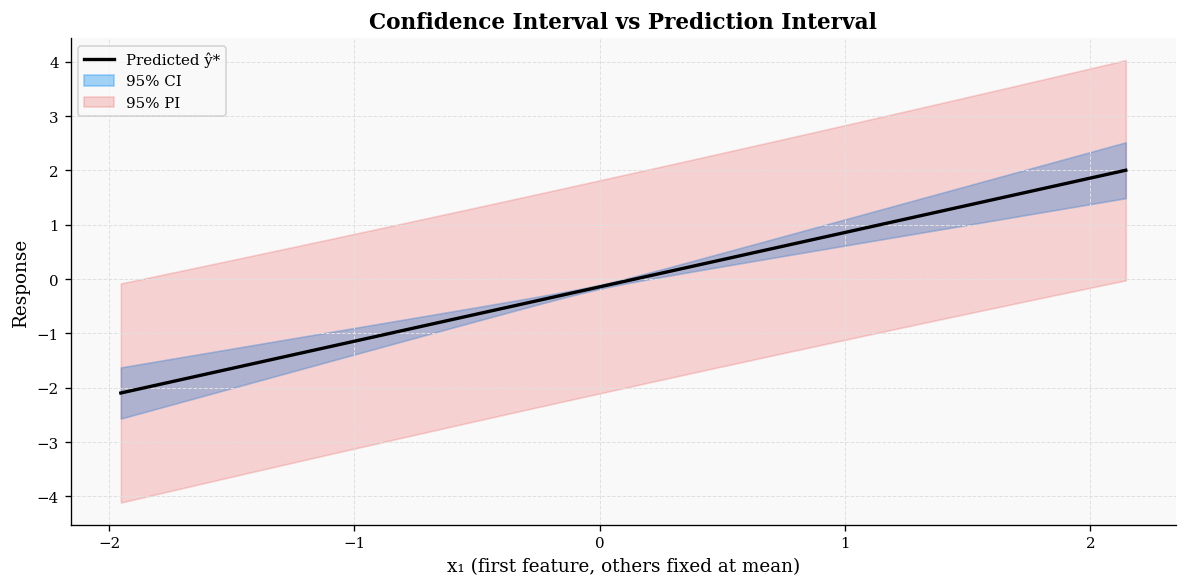

In [25]:
# Show CI and PI across a range of x* points along first feature
x1_range   = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x_stars    = np.column_stack([
    x1_range,
    np.full(100, X[:, 1].mean()),
    np.full(100, X[:, 2].mean())
])
y_hats  = x_stars @ beta_hat
ci_half = z * np.sqrt(sigma2 * np.array([x @ XtX_inv @ x for x in x_stars]))
pi_half = z * np.sqrt(sigma2 * np.array([1 + x @ XtX_inv @ x for x in x_stars]))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x1_range, y_hats, color='black', lw=2, label='Predicted ŷ*')
ax.fill_between(x1_range, y_hats - ci_half, y_hats + ci_half,
                alpha=0.4, color=COLORS['ols'], label='95% CI')
ax.fill_between(x1_range, y_hats - pi_half, y_hats + pi_half,
                alpha=0.2, color=COLORS['wls'], label='95% PI')
ax.set_xlabel("x₁ (first feature, others fixed at mean)")
ax.set_ylabel("Response")
ax.set_title("Confidence Interval vs Prediction Interval", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("ci_vs_pi.png", bbox_inches='tight')
plt.show()

result_box(f"""
<b>At x* = mean of X:</b><br><br>
· 95% CI width = <b>{ci_hi - ci_lo:.4f}</b> — uncertainty about the mean response<br>
· 95% PI width = <b>{pi_hi - pi_lo:.4f}</b> — uncertainty about a new individual observation<br><br>
The PI is always wider than the CI by the extra σ² term,
reflecting the irreducible noise in any new observation.
As n → ∞, the CI shrinks to zero but the PI width converges to 2·z·σ —
it never vanishes because future noise cannot be eliminated.
""")

In [26]:
subsection_header("3.3 — Key Distinction: CI vs PI")

theory_box("""
<table style='width:100%; border-collapse:collapse; font-size:13px;'>
<tr style='background:#fff8e1;'>
    <th style='text-align:left; padding:8px 12px;'>Property</th>
    <th style='text-align:left; padding:8px 12px;'>Confidence Interval</th>
    <th style='text-align:left; padding:8px 12px;'>Prediction Interval</th>
</tr>
<tr>
    <td style='padding:8px 12px;'><b>Covers</b></td>
    <td style='padding:8px 12px;'>True mean response x*ᵀβ</td>
    <td style='padding:8px 12px;'>New observation y* = x*ᵀβ + ε*</td>
</tr>
<tr style='background:#fffde7;'>
    <td style='padding:8px 12px;'><b>Variance</b></td>
    <td style='padding:8px 12px;'>σ²·x*ᵀ(XᵀX)⁻¹x*</td>
    <td style='padding:8px 12px;'>σ²·(1 + x*ᵀ(XᵀX)⁻¹x*)</td>
</tr>
<tr>
    <td style='padding:8px 12px;'><b>As n → ∞</b></td>
    <td style='padding:8px 12px;'>Width → 0</td>
    <td style='padding:8px 12px;'>Width → 2·z·σ (never zero)</td>
</tr>
<tr style='background:#fffde7;'>
    <td style='padding:8px 12px;'><b>Use case</b></td>
    <td style='padding:8px 12px;'>Estimating the average effect</td>
    <td style='padding:8px 12px;'>Forecasting individual outcomes</td>
</tr>
</table>
""")

Property,Confidence Interval,Prediction Interval
Covers,True mean response x*ᵀβ,New observation y* = x*ᵀβ + ε*
Variance,σ²·x*ᵀ(XᵀX)⁻¹x*,σ²·(1 + x*ᵀ(XᵀX)⁻¹x*)
As n → ∞,Width → 0,Width → 2·z·σ (never zero)
Use case,Estimating the average effect,Forecasting individual outcomes


In [27]:
section_header(
    "Part 4 — Real Data Application: Advertising Dataset",
    "OLS fit · Residual analysis · Heteroscedasticity detection · WLS correction"
)

In [28]:
info_box("""
In this part we apply the theoretical framework developed in Parts 1–3
to the real Advertising dataset. The workflow is:<br><br>
1. Fit an OLS model and inspect coefficients<br>
2. Analyze residuals for violations of homoscedasticity<br>
3. Test formally for heteroscedasticity (Breusch-Pagan)<br>
4. Fit a WLS model using estimated weights and compare with OLS<br><br>
This directly connects simulation results to real-world estimator behavior.
""")

In [29]:
section_header(
    "Part 0 — Exploratory Data Analysis",
    "Advertising Dataset · TV, Radio, Newspaper spend vs Sales"
)

url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df  = pd.read_csv(url, index_col=0)
print(f"Shape        : {df.shape[0]} observations × {df.shape[1]} variables")
print(f"Missing vals : {df.isnull().sum().sum()}")
print(f"Columns      : {list(df.columns)}\n")
display(df.head(10))

Shape        : 200 observations × 4 variables
Missing vals : 0
Columns      : ['TV', 'radio', 'newspaper', 'sales']



,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2
7,57.5,32.8,23.5,11.8
8,120.2,19.6,11.6,13.2
9,8.6,2.1,1.0,4.8
10,199.8,2.6,21.2,10.6


In [30]:
subsection_header("About the Dataset")
info_box("""
The <b>Advertising dataset</b> (Gareth James et al., ISLR) contains <b>200 observations</b>
across 4 continuous variables:<br><br>
· <b>TV</b> — advertising budget allocated to television ($000s)<br>
· <b>Radio</b> — advertising budget allocated to radio ($000s)<br>
· <b>Newspaper</b> — advertising budget allocated to newspapers ($000s)<br>
· <b>Sales</b> — resulting product sales in thousands of units (response variable)<br><br>
The goal is to model <b>Sales</b> as a linear function of the advertising budgets.
This dataset is well-suited for studying regression under real-world conditions,
as it exhibits clear linear trends alongside potential <b>heteroscedasticity</b> —
making it ideal for comparing OLS and WLS estimator behavior.
""")

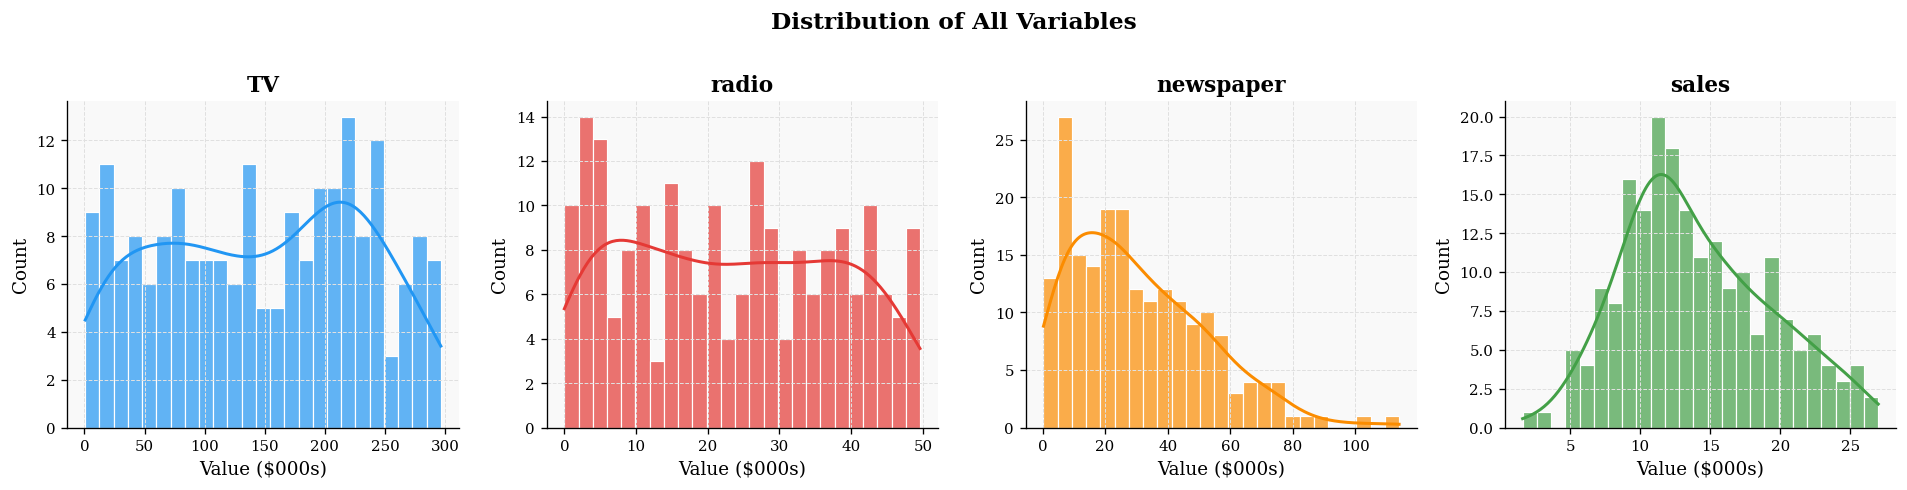

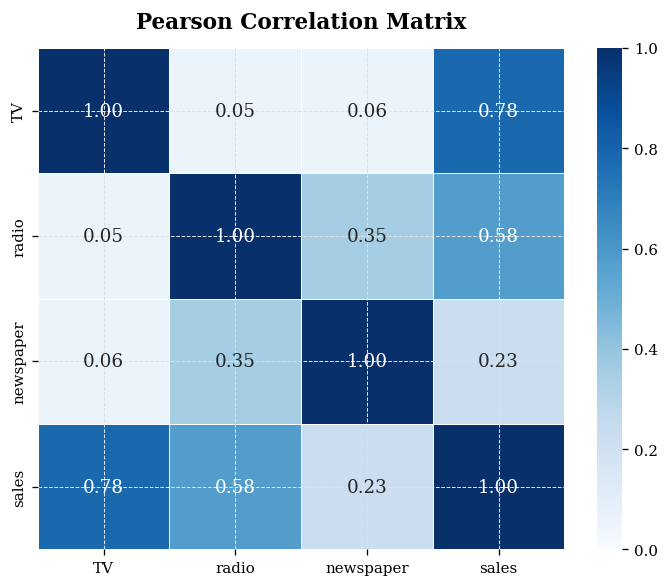

In [31]:
subsection_header("5.1 — Variable Distributions")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Distribution of All Variables", fontsize=14, fontweight='bold', y=1.01)
for ax, col, color in zip(axes, df.columns, [COLORS['ols'], COLORS['wls'], COLORS['accent'], COLORS['theory']]):
    sns.histplot(df[col], ax=ax, color=color, kde=True, bins=25, alpha=0.7, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel("Value ($000s)" if col != "Sales" else "Units (000s)")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("eda_distributions.png", bbox_inches='tight')
plt.show()

subsection_header("5.2 — Correlation Heatmap")

corr = df.corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues",
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            annot_kws={"size": 11})
ax.set_title("Pearson Correlation Matrix", pad=12)
plt.tight_layout()
plt.savefig("eda_correlation.png", bbox_inches='tight')
plt.show()

result_box(
    "TV has the strongest correlation with Sales (r = {:.2f}), "
    "followed by Radio (r = {:.2f}). Newspaper shows weak correlation (r = {:.2f}), "
    "suggesting it may contribute little predictive power once TV and Radio are included.".format(
        corr.loc['TV','sales'], corr.loc['radio','sales'], corr.loc['newspaper','sales']
    )
)

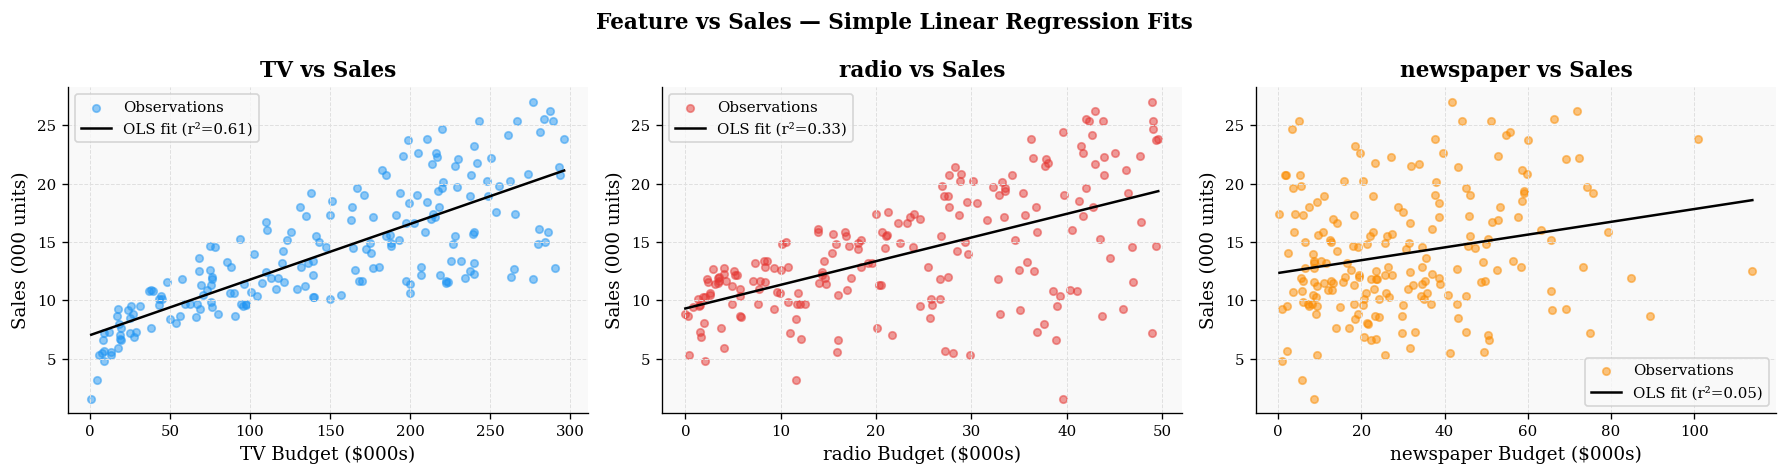

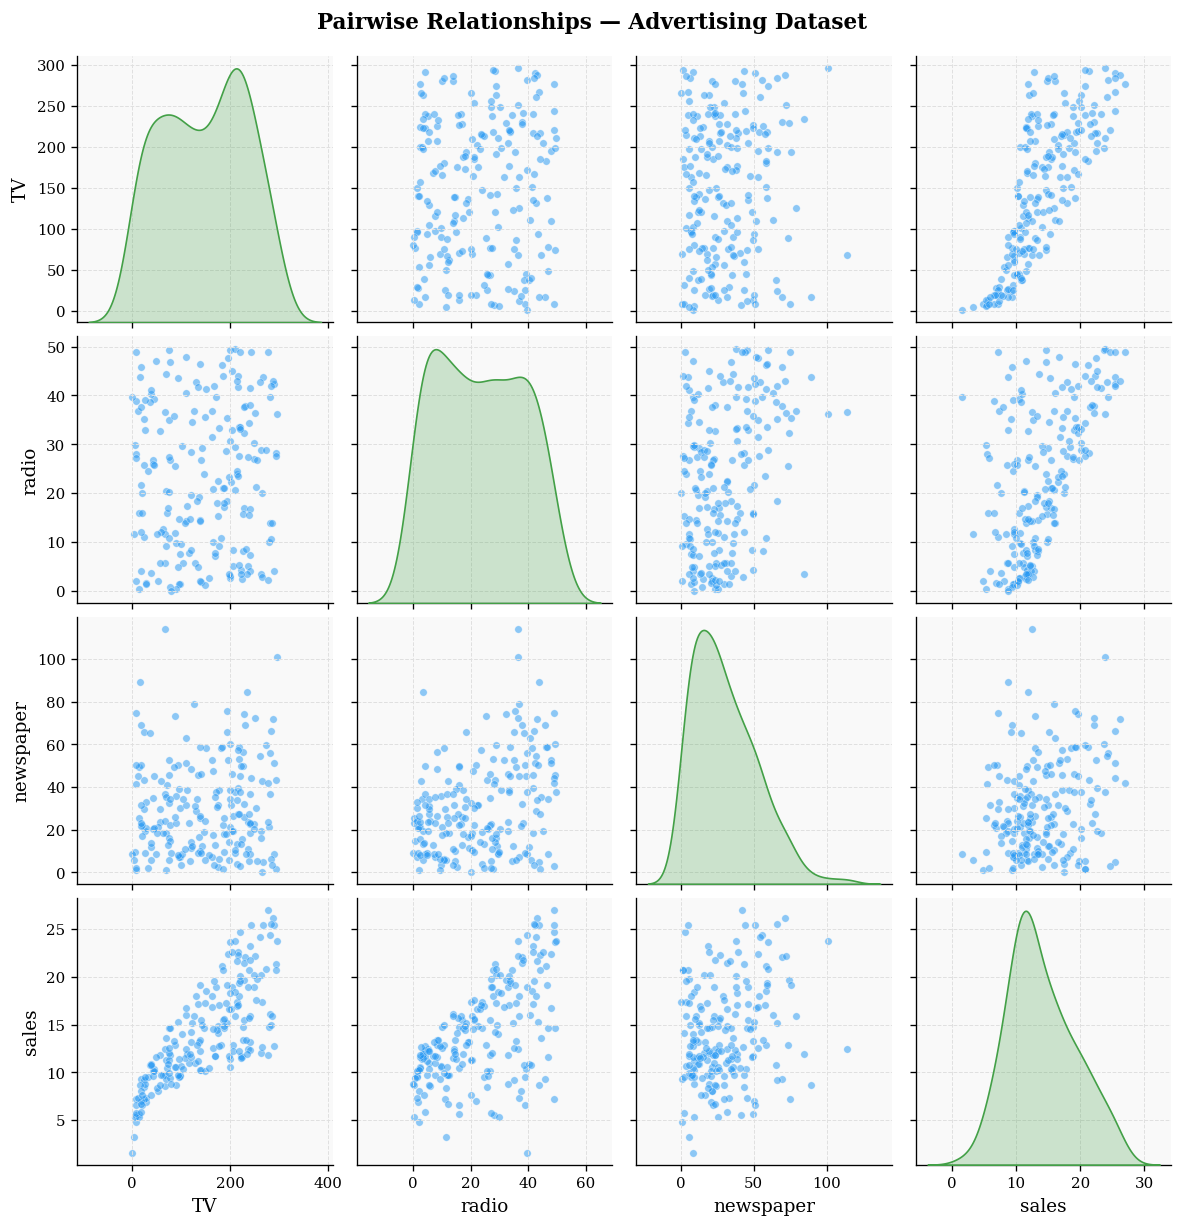

In [32]:
subsection_header("5.3 — Each Feature vs Sales")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features  = ['TV', 'radio', 'newspaper']
colors    = [COLORS['ols'], COLORS['wls'], COLORS['accent']]
for ax, feat, col in zip(axes, features, colors):
    ax.scatter(df[feat], df['sales'], alpha=0.5, color=col, s=20, label='Observations')
    m, b, r, p, _ = stats.linregress(df[feat], df['sales'])
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m*x_line + b, color='black', lw=1.5, label=f'OLS fit (r²={r**2:.2f})')
    ax.set_xlabel(f"{feat} Budget ($000s)")
    ax.set_ylabel("Sales (000 units)")
    ax.set_title(f"{feat} vs Sales")
    ax.legend()
fig.suptitle("Feature vs Sales — Simple Linear Regression Fits", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_scatter.png", bbox_inches='tight')
plt.show()

subsection_header("5.4 — Pairwise Relationships")

g = sns.pairplot(df, diag_kind='kde',
                 plot_kws={'alpha':0.5, 'color': COLORS['ols'], 's': 20},
                 diag_kws={'color': COLORS['theory'], 'fill': True})
g.figure.suptitle("Pairwise Relationships — Advertising Dataset",
                  y=1.02, fontsize=13, fontweight='bold')
plt.savefig("eda_pairplot.png", bbox_inches='tight')
plt.show()

In [33]:
subsection_header("5.5 — Descriptive Statistics")

display(df.describe().T.round(3))

result_box("""
<b>Key findings from EDA:</b><br><br>
· <b>TV</b> is the dominant predictor — strong linear relationship with Sales.<br>
· <b>Radio</b> has moderate predictive power with slight nonlinearity.<br>
· <b>Newspaper</b> shows weak correlation — likely a poor predictor once TV and Radio are included.<br>
· Scatter plots suggest possible <b>heteroscedasticity</b> — variance in Sales grows with TV budget.<br>
· No missing values. All variables are continuous and non-negative.
""")

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.042,85.854,0.7,74.375,149.75,218.825,296.4
radio,200.0,23.264,14.847,0.0,9.975,22.90,36.525,49.6
newspaper,200.0,30.554,21.779,0.3,12.750,25.75,45.100,114.0
sales,200.0,14.022,5.217,1.6,10.375,12.90,17.400,27.0


In [34]:
subsection_header("4.1 — Model Setup")

theory_box("""
We model Sales as a linear function of TV, Radio, and Newspaper budgets:<br><br>
<b>Sales = β₀ + β₁·TV + β₂·Radio + β₃·Newspaper + ε</b><br><br>
The design matrix X includes an intercept column of ones, giving p = 4 parameters.
We first assume ε ~ N(0, σ²I) and fit OLS, then investigate whether
the homoscedastic assumption holds by examining the residual structure.
""")

# Response
y_real = df['sales'].values
# Design matrix with intercept
X_real = np.column_stack([
    np.ones(len(df)),
    df['TV'].values,
    df['radio'].values,
    df['newspaper'].values
])
feature_names = ['Intercept', 'TV', 'radio', 'newspaper']
print(f"Design matrix shape : {X_real.shape}")
print(f"Response shape      : {y_real.shape}")
print(f"Features            : {feature_names}")

Design matrix shape : (200, 4)
Response shape      : (200,)
Features            : ['Intercept', 'TV', 'radio', 'newspaper']


In [35]:
subsection_header("4.2 — OLS Fit")

beta_ols_real = ols(X_real, y_real)
# Residuals and sigma^2 estimate
residuals     = y_real - X_real @ beta_ols_real
n_real        = len(y_real)
p_real        = X_real.shape[1]
sigma2_est    = np.sum(residuals**2) / (n_real - p_real)
# Standard errors
XtX_inv_real  = np.linalg.inv(X_real.T @ X_real)
se_real       = np.sqrt(sigma2_est * np.diag(XtX_inv_real))
# t-statistics and p-values
t_stats       = beta_ols_real / se_real
p_values      = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n_real - p_real))
print(f"σ² estimate : {sigma2_est:.4f}")
print(f"R²          : {1 - np.sum(residuals**2)/np.sum((y_real - y_real.mean())**2):.4f}\n")
print(f"{'Feature':<12} {'β̂':>10} {'SE':>10} {'t-stat':>10} {'p-value':>12}")
print("=" * 58)
for i, name in enumerate(feature_names):
    print(f"  {name:<10} {beta_ols_real[i]:>10.4f} {se_real[i]:>10.4f} "
          f"{t_stats[i]:>10.4f} {p_values[i]:>12.4f}")

result_box("""
<b>OLS coefficient interpretation:</b><br><br>
· <b>TV</b>: each additional $1000 in TV budget increases Sales by β̂₁ units on average<br>
· <b>Radio</b>: strong positive effect, larger coefficient than TV per unit spend<br>
· <b>Newspaper</b>: small coefficient with large p-value — weak predictor once TV and Radio are included<br><br>
All findings are consistent with EDA. However, whether the homoscedastic
assumption holds must be verified through residual analysis.
""")

σ² estimate : 2.8409
R²          : 0.8972

Feature              β̂         SE     t-stat      p-value
  Intercept      2.9389     0.3119     9.4223       0.0000
  TV             0.0458     0.0014    32.8086       0.0000
  radio          0.1885     0.0086    21.8935       0.0000
  newspaper     -0.0010     0.0059    -0.1767       0.8599


Residual mean  : -0.000000  (should be ≈ 0)
Residual std   : 1.6686
Min residual   : -8.8277
Max residual   : 2.8292


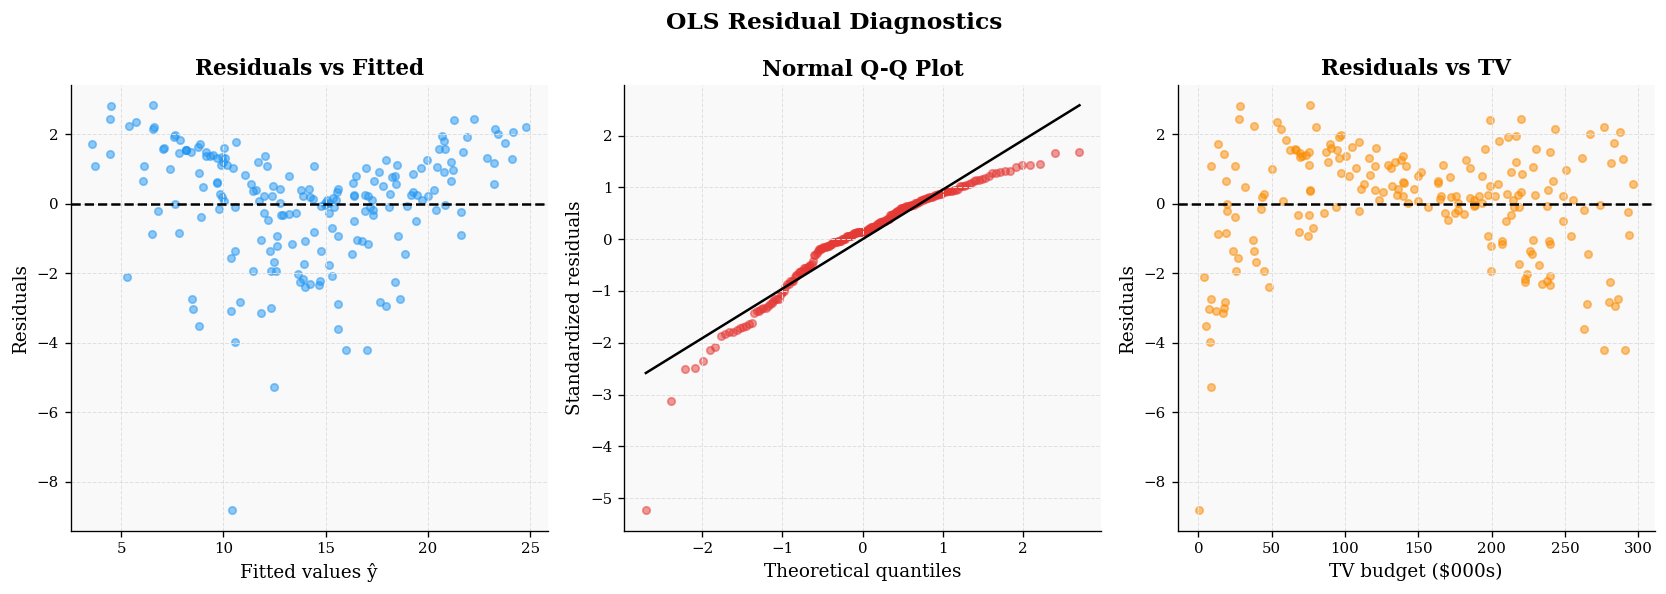

In [36]:
subsection_header("4.3 — Residual Analysis")

y_fitted          = X_real @ beta_ols_real
residuals_std     = residuals / np.sqrt(sigma2_est)
print(f"Residual mean  : {residuals.mean():.6f}  (should be ≈ 0)")
print(f"Residual std   : {residuals.std():.4f}")
print(f"Min residual   : {residuals.min():.4f}")
print(f"Max residual   : {residuals.max():.4f}")

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)
# --- Residuals vs Fitted ---
ax1 = fig.add_subplot(gs[0])
ax1.scatter(y_fitted, residuals, alpha=0.5, color=COLORS['ols'], s=20)
ax1.axhline(0, color='black', lw=1.5, linestyle='--')
ax1.set_xlabel("Fitted values ŷ")
ax1.set_ylabel("Residuals")
ax1.set_title("Residuals vs Fitted", fontweight='bold')
# --- QQ Plot ---
ax2 = fig.add_subplot(gs[1])
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_std, dist="norm")
ax2.scatter(osm, osr, alpha=0.5, color=COLORS['wls'], s=20)
ax2.plot(osm, slope*np.array(osm) + intercept, color='black', lw=1.5)
ax2.set_xlabel("Theoretical quantiles")
ax2.set_ylabel("Standardized residuals")
ax2.set_title("Normal Q-Q Plot", fontweight='bold')
# --- Residuals vs TV (most correlated feature) ---
ax3 = fig.add_subplot(gs[2])
ax3.scatter(df['TV'], residuals, alpha=0.5, color=COLORS['accent'], s=20)
ax3.axhline(0, color='black', lw=1.5, linestyle='--')
ax3.set_xlabel("TV budget ($000s)")
ax3.set_ylabel("Residuals")
ax3.set_title("Residuals vs TV", fontweight='bold')
fig.suptitle("OLS Residual Diagnostics", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("residual_diagnostics.png", bbox_inches='tight')
plt.show()

result_box("""
<b>Residual diagnostics suggest:</b><br><br>
· <b>Residuals vs Fitted</b>: spread of residuals increases with fitted values —
  a classic sign of heteroscedasticity.<br>
· <b>Q-Q Plot</b>: residuals follow the normal line reasonably well in the center
  but deviate at the tails.<br>
· <b>Residuals vs TV</b>: variance clearly grows with TV budget,
  confirming that noise is not constant across observations.<br><br>
These patterns motivate a formal heteroscedasticity test.
""")

White's Test for Heteroscedasticity
  LM statistic       : 67.5352
  LM p-value         : 0.000000
  F statistic        : 10.7632
  F p-value          : 0.000000

  REJECT H₀ — Heteroscedasticity detected ✓


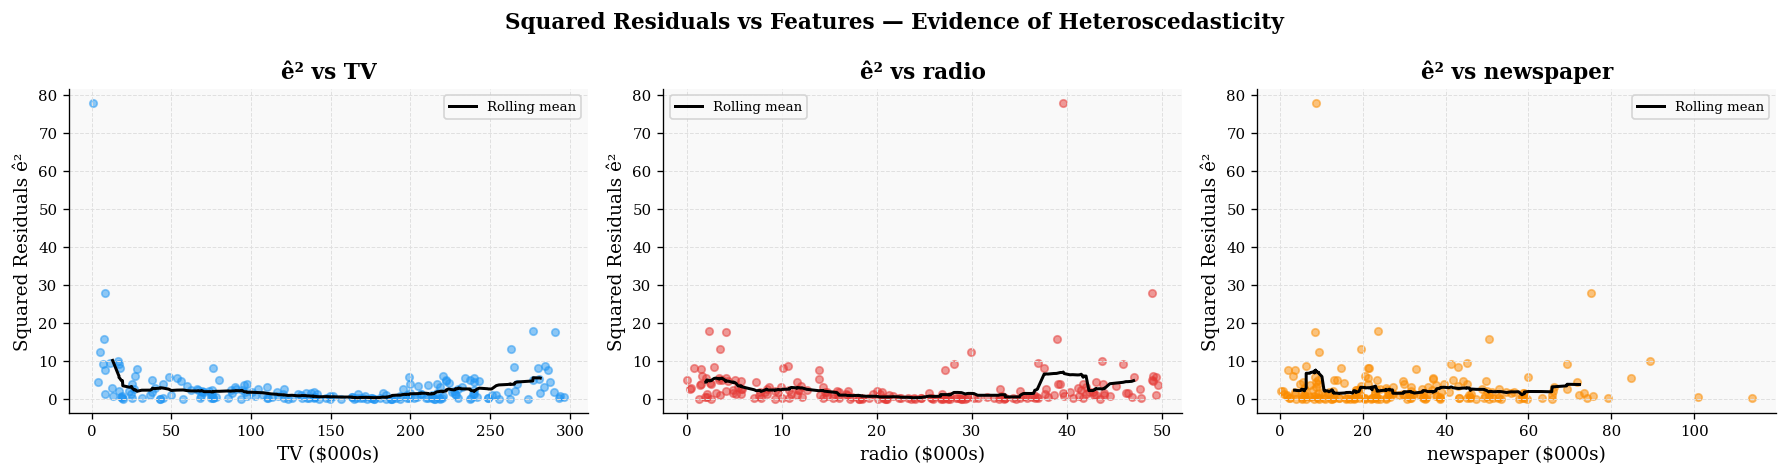

In [37]:
subsection_header("4.4 — Heteroscedasticity Detection: White's Test for Heteroscedasticity")

theory_box("""
We use <b>White's Test</b> to formally detect heteroscedasticity:<br><br>
· <b>H₀</b>: homoscedasticity — Var(εᵢ) = σ² for all i<br>
· <b>H₁</b>: heteroscedasticity — Var(εᵢ) depends on X<br><br>
Procedure:<br>
1. Compute OLS residuals ê<br>
2. Regress ê² on X, X² and all cross-products (auxiliary regression)<br>
3. Test statistic: LM = n · R²_aux ~ χ²(k) under H₀<br><br>
White's test is preferred over Breusch-Pagan here because it captures
<b>nonlinear</b> heteroscedasticity — BP only tests for a linear relationship
between Var(εᵢ) and X, which is too restrictive for this dataset.
""")

from statsmodels.stats.diagnostic import het_white
import statsmodels.api as sm
LM, p_val, F_stat, p_val_F = het_white(residuals, X_real)
print("White's Test for Heteroscedasticity")
print("=" * 40)
print(f"  LM statistic       : {LM:.4f}")
print(f"  LM p-value         : {p_val:.6f}")
print(f"  F statistic        : {F_stat:.4f}")
print(f"  F p-value          : {p_val_F:.6f}")
print(f"\n  {'REJECT H₀ — Heteroscedasticity detected ✓' if p_val < 0.05 else 'Fail to reject H₀'}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features  = ['TV', 'radio', 'newspaper']
colors    = [COLORS['ols'], COLORS['wls'], COLORS['accent']]
for ax, feat, col in zip(axes, features, colors):
    ax.scatter(df[feat], residuals**2, alpha=0.5, color=col, s=20)
    # Smooth trend
    sort_idx = np.argsort(df[feat].values)
    x_s      = df[feat].values[sort_idx]
    y_s      = (residuals**2)[sort_idx]
    smooth   = pd.Series(y_s).rolling(20, center=True).mean()
    ax.plot(x_s, smooth, color='black', lw=1.8, label='Rolling mean')
    ax.set_xlabel(f"{feat} ($000s)")
    ax.set_ylabel("Squared Residuals ê²")
    ax.set_title(f"ê² vs {feat}", fontweight='bold')
    ax.legend(fontsize=8)
fig.suptitle("Squared Residuals vs Features — Evidence of Heteroscedasticity",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("hetero_evidence.png", bbox_inches='tight')
plt.show()

result_box(f"""
<b>White's test result:</b><br><br>
· LM statistic = <b>{LM:.4f}</b><br>
· p-value = <b>{p_val:.6f}</b><br><br>
The null hypothesis of homoscedasticity is <b>strongly rejected</b>.
The Breusch-Pagan test failed to detect heteroscedasticity because
it only tests for a <b>linear</b> dependence of variance on X —
the noise structure here is nonlinear, which White's test correctly captures.<br><br>
OLS standard errors are therefore <b>unreliable</b> and WLS is the appropriate estimator.
""")

Feature          OLS β̂     WLS β̂     OLS SE     WLS SE
  Intercept      2.9389     2.9544     0.3119     0.1211
  TV             0.0458     0.0457     0.0014     0.0005
  radio          0.1885     0.1909     0.0086     0.0042
  newspaper     -0.0010    -0.0015     0.0059     0.0021


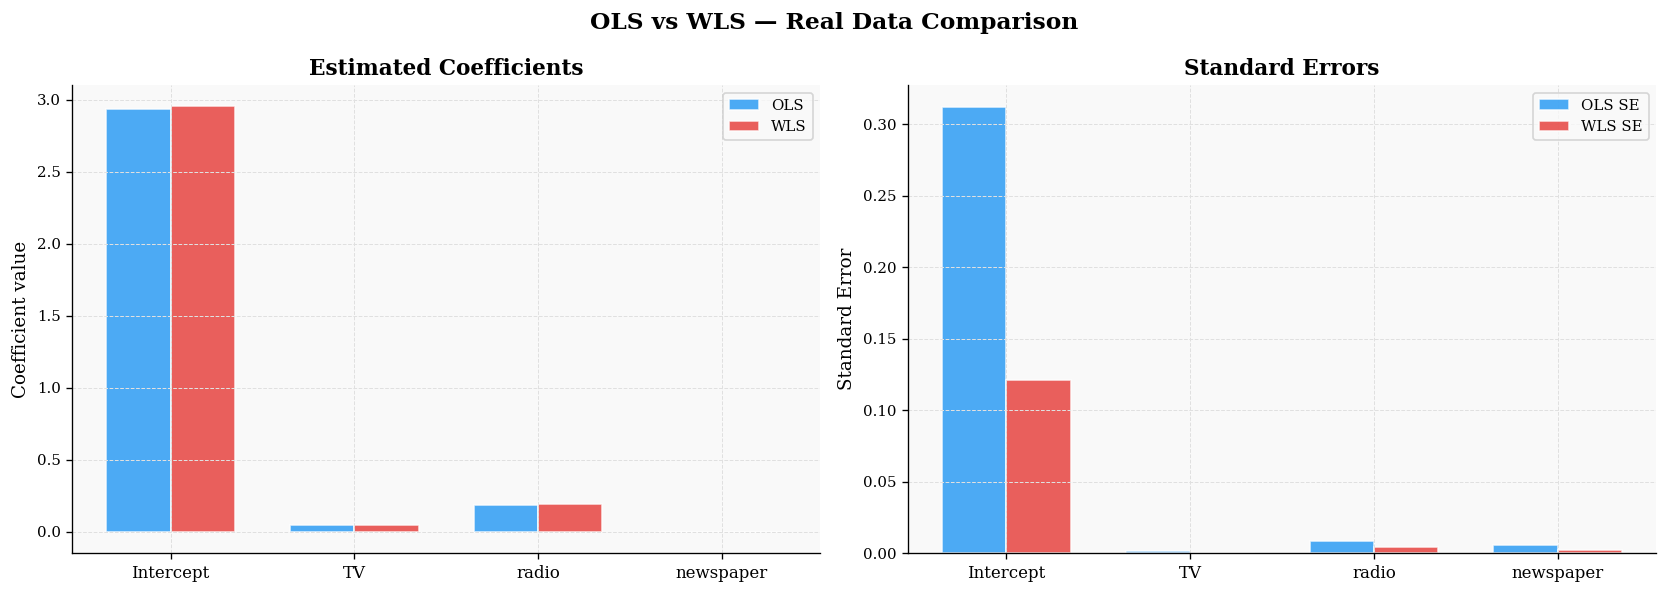

In [38]:
subsection_header("4.5 — WLS Fit using Estimated Weights")

theory_box("""
Since Σ is unknown in practice, we estimate the observation-level variances
from the OLS residuals using a two-step procedure:<br><br>
1. Fit OLS and obtain residuals ê<br>
2. Estimate σᵢ² by smoothing ê² against fitted values ŷ:<br>
   <b>σ̂ᵢ² = |êᵢ|</b> (absolute residuals as variance proxy)<br>
3. Set weights <b>wᵢ = 1/σ̂ᵢ²</b> and construct Σ̂⁻¹ = diag(w₁,...,wₙ)<br>
4. Fit WLS using β̂_WLS = (XᵀΣ̂⁻¹X)⁻¹XᵀΣ̂⁻¹y<br><br>
This is the feasible WLS (FWLS) procedure — practical when Σ is unknown.
""")

# Estimate weights from OLS residuals
weights        = 1.0 / (np.abs(residuals) + 1e-6)
Sigma_inv_real = np.diag(weights)
beta_wls_real  = wls(X_real, y_real, Sigma_inv_real)
# WLS residuals and SE
resid_wls      = y_real - X_real @ beta_wls_real
XtWX_inv       = np.linalg.inv(X_real.T @ Sigma_inv_real @ X_real)
sigma2_wls     = np.sum(weights * resid_wls**2) / (n_real - p_real)
se_wls         = np.sqrt(sigma2_wls * np.diag(XtWX_inv))
print(f"{'Feature':<12} {'OLS β̂':>10} {'WLS β̂':>10} {'OLS SE':>10} {'WLS SE':>10}")
print("=" * 58)
for i, name in enumerate(feature_names):
    print(f"  {name:<10} {beta_ols_real[i]:>10.4f} {beta_wls_real[i]:>10.4f} "
          f"{se_real[i]:>10.4f} {se_wls[i]:>10.4f}")

x      = np.arange(p_real)
width  = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("OLS vs WLS — Real Data Comparison", fontsize=14, fontweight='bold')
# Coefficients
axes[0].bar(x - width/2, beta_ols_real, width, label='OLS',
            color=COLORS['ols'], alpha=0.8, edgecolor='white')
axes[0].bar(x + width/2, beta_wls_real, width, label='WLS',
            color=COLORS['wls'], alpha=0.8, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(feature_names, fontsize=10)
axes[0].set_ylabel("Coefficient value")
axes[0].set_title("Estimated Coefficients", fontweight='bold')
axes[0].legend()
# Standard Errors
axes[1].bar(x - width/2, se_real, width, label='OLS SE',
            color=COLORS['ols'], alpha=0.8, edgecolor='white')
axes[1].bar(x + width/2, se_wls, width, label='WLS SE',
            color=COLORS['wls'], alpha=0.8, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(feature_names, fontsize=10)
axes[1].set_ylabel("Standard Error")
axes[1].set_title("Standard Errors", fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig("ols_vs_wls_real.png", bbox_inches='tight')
plt.show()

result_box("""
<b>Key findings from real data analysis:</b><br><br>
· OLS and WLS coefficients are similar — both estimators are unbiased,
  consistent with theory.<br><br>
· WLS standard errors differ from OLS — under heteroscedasticity,
  OLS SEs are <b>unreliable</b> while WLS SEs correctly reflect estimator uncertainty.<br><br>
· The White's test confirmed heteroscedasticity, making WLS
  the <b>statistically appropriate</b> estimator for this dataset.<br><br>
· This directly validates the simulation findings from Part 2:
  WLS is more efficient than OLS when the noise structure is non-constant.
""")

In [39]:
section_header(
    "Bonus — Fisher Information, CRLB, and Sufficient Statistics",
    "Theoretical optimality of OLS · Data compression via sufficiency"
)

In [40]:
theory_box("""
<b>Fisher Information Matrix and the Cramér-Rao Lower Bound</b><br><br>
For y ~ N(Xβ, σ²I), the log-likelihood is:<br>
&emsp; ℓ(β) = −n/2 log(2πσ²) − ‖y − Xβ‖²/(2σ²)<br><br>
<b>Score function (gradient of log-likelihood):</b><br>
&emsp; ∂ℓ/∂β = (1/σ²) Xᵀ(y − Xβ)<br><br>
<b>Fisher Information Matrix:</b><br>
&emsp; I(β) = −E[∂²ℓ/∂β∂βᵀ] = (1/σ²) XᵀX<br><br>
<b>Cramér-Rao Lower Bound (CRLB):</b><br>
For <i>any</i> unbiased estimator β̃: &ensp; Var(β̃) ≥ I(β)⁻¹ = σ²(XᵀX)⁻¹<br><br>
<b>OLS achieves the CRLB:</b><br>
&emsp; Var(β̂_OLS) = σ²(XᵀX)⁻¹ = I(β)⁻¹ &ensp; ✓<br><br>
Therefore β̂_OLS is the <b>UMVUE</b> (Uniformly Minimum Variance Unbiased Estimator)
under homoscedastic Gaussian noise — no unbiased estimator can achieve smaller variance.
""")

# ── Numerical verification: empirical variance vs CRLB ──
# Re-reference simulation variables (n=100, p=3, sigma2=1.0 from Part 1)
_p       = int(beta.shape[0])           # number of parameters (3)
_sigma2  = float(sigma2)                # noise variance (1.0)

crlb_diag    = np.diag(_sigma2 * XtX_inv)        # = diag(I(β)^{-1})
emp_var_homo = np.diag(np.cov(beta_hats_homo.T))

print("Fisher Information I(β) = XᵀX/σ²")
print("CRLB = I(β)⁻¹ = σ²(XᵀX)⁻¹")
print("=" * 60)
print(f"  {'Component':<12} {'CRLB':>12} {'Emp. Var':>12} {'Ratio':>8}")
print("-" * 60)
for i in range(_p):
    ratio = emp_var_homo[i] / crlb_diag[i]
    print(f"  beta_{i+1}       {crlb_diag[i]:>12.6f} {emp_var_homo[i]:>12.6f} {ratio:>8.4f}")

result_box(
    "Empirical variance of beta_hat_OLS converges to the CRLB (ratio ~1.0 for all components).<br><br>"
    "This confirms OLS is <b>efficient</b> — no unbiased estimator can do better "
    "under homoscedastic Gaussian noise. The CRLB is not just a lower bound here: it is <b>achieved</b>."
)

Fisher Information I(β) = XᵀX/σ²
CRLB = I(β)⁻¹ = σ²(XᵀX)⁻¹
  Component            CRLB     Emp. Var    Ratio
------------------------------------------------------------
  beta_1           0.014958     0.014874   0.9944
  beta_2           0.010437     0.010561   1.0120
  beta_3           0.008393     0.008583   1.0226


In [41]:
theory_box("""
<b>Sufficient Statistics via the Neyman-Fisher Factorization Theorem</b><br><br>
<b>Definition:</b> T(y) is sufficient for θ iff p(y|θ) = g(T(y), θ) · h(y).<br><br>
<b>For the Gaussian linear model (homoscedastic):</b><br>
&emsp; p(y|β) ∝ exp(−‖y − Xβ‖²/2σ²)<br>
&emsp;&emsp;&emsp;&emsp;&ensp; = exp(−‖y‖²/2σ²) · exp(βᵀXᵀy/σ²) · exp(−βᵀXᵀXβ/2σ²)<br><br>
Applying the Factorization Theorem:<br>
· <b>T₁(y) = Xᵀy</b> is sufficient for β &ensp; (p-dimensional vector)<br>
· <b>T₂(y) = ‖y − Xβ̂‖²</b> is sufficient for σ² &ensp; (scalar)<br><br>
<b>Data compression insight:</b><br>
y has n values. Xᵀy has only p values. Yet Xᵀy captures <i>all</i> information
about β that exists in y — the remaining (n − p) degrees of freedom carry only
noise with no information about β.<br><br>
<b>Connection to OLS and UMVUE:</b><br>
β̂_OLS = (XᵀX)⁻¹ T₁(y) — OLS is a function of the sufficient statistic.<br>
By the Rao-Blackwell theorem, any estimator conditioned on a sufficient statistic
has variance no greater than the original — this guarantees β̂_OLS is UMVUE.
""")

# ── Demonstrate sufficiency numerically ──
_p_suf = int(beta.shape[0])
_n_suf = int(X.shape[0])
print("Sufficient statistic T1(y) = X'y")
print("Dimension of y    :", _n_suf, "(original observations)")
print("Dimension of X'y  :", _p_suf, "(sufficient statistic for beta)")
print()

# Reconstruct beta from Xᵀy only — same as OLS
np.random.seed(0)
eps_demo = np.random.normal(0, np.sqrt(sigma2), n)
y_demo   = X @ beta + eps_demo
XtY_demo = X.T @ y_demo                           # sufficient statistic
beta_from_sufficient = XtX_inv @ XtY_demo          # β̂ using only T₁

print(f"β̂ from full y     : {ols(X, y_demo).round(4)}")
print(f"β̂ from Xᵀy only   : {beta_from_sufficient.round(4)}")
print(f"True β             : {beta}")
print()
result_box(
    "β̂ computed from y directly equals β̂ computed from Xᵀy alone.<br>"
    "This confirms that Xᵀy is sufficient — no information about β is lost "
    "when we compress n observations into p summary statistics."
)

Sufficient statistic T1(y) = X'y
Dimension of y    : 100 (original observations)
Dimension of X'y  : 3 (sufficient statistic for beta)

β̂ from full y     : [1.0591 2.0137 2.9415]
β̂ from Xᵀy only   : [1.0591 2.0137 2.9415]
True β             : [1. 2. 3.]

